# Notebook 01 — SHREC 2017 Data Preparation

This notebook walks through the **complete data preparation pipeline** for both the skeleton and depth-map modalities.
Run each section in order. Re-run individual sections as needed during development.

## Table of Contents
1. [Environment & Imports](#1)
2. [Dataset Sanity Check](#2)
3. [Visualise One Raw Clip (Depth + Skeleton)](#3)
4. [Explain: Why 64×64? Why Crop?](#4)
5. [Preprocess — Skeleton Modality](#5)
6. [Preprocess — Depth Map Modality](#6)
7. [Verify Processed Tensors & Class Distribution](#7)
8. [Augmentation Preview](#8)


---
## 1. Environment & Imports <a id='1'></a>

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebook
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm
import torch

from config import (
    RAW_DIR, PROC_DIR,
    TRAIN_SPLIT_FILE, TEST_SPLIT_FILE,
    DEPTH_RESIZE, DEPTH_MAX_MM,
    WINDOW_T, STRIDE,
    PROC_SKELETON_TRAIN, PROC_SKELETON_VAL, PROC_SKELETON_TEST,
    PROC_DEPTH_TRAIN, PROC_DEPTH_VAL, PROC_DEPTH_TEST,
)
from shrec_io import (
    parse_manifest, clip_dir,
    load_skeleton_world, load_skeleton_image,
    load_depth_frames, load_bboxes,
)
from preprocess_skeleton import normalise_clip, sliding_windows, augment_skeleton
from preprocess_depth    import process_depth_clip, sliding_windows_depth, augment_depth
from dataset import SkeletonDataset, DepthDataset

print(f'RAW_DIR  exists: {RAW_DIR.exists()}')
print(f'PROC_DIR exists: {PROC_DIR.exists()}')
print(f'Train manifest : {TRAIN_SPLIT_FILE.exists()}')
print(f'Test  manifest : {TEST_SPLIT_FILE.exists()}')

RAW_DIR  exists: True
PROC_DIR exists: True
Train manifest : True
Test  manifest : True


---
## 2. Dataset Sanity Check <a id='2'></a>
Verify the manifest files, count clips, and spot-check directory structure.

Train clips: 1960   Test clips: 840
Columns: id_gesture  id_finger  id_subject  id_essai  label_14  label_28  seq_len
First 5 training rows:
[[  1   1   2   1   1   1  77]
 [  1   1   2   2   1   1 117]
 [  1   1   2   3   1   1  92]
 [  1   1   2   4   1   1  82]
 [  1   1   3   1   1   1  71]]

Sequence length — min: 11  max: 171  mean: 58.8


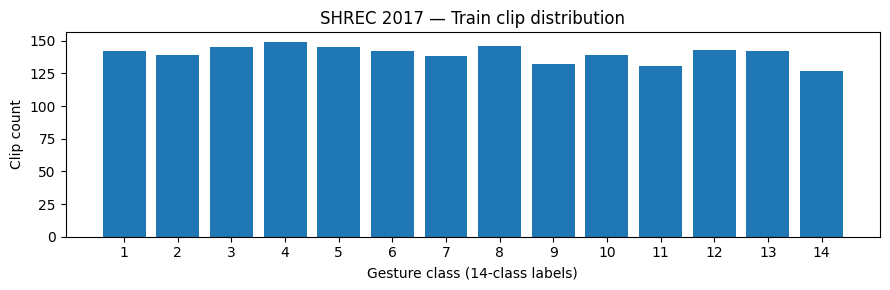

In [2]:
train_mf = parse_manifest(TRAIN_SPLIT_FILE)  # (1960, 7)
test_mf  = parse_manifest(TEST_SPLIT_FILE)   # (840, 7)

print(f'Train clips: {len(train_mf)}   Test clips: {len(test_mf)}')
print('Columns: id_gesture  id_finger  id_subject  id_essai  label_14  label_28  seq_len')
print('First 5 training rows:')
print(train_mf[:5])
print(f'\nSequence length — min: {train_mf[:,6].min()}  '
      f'max: {train_mf[:,6].max()}  '
      f'mean: {train_mf[:,6].mean():.1f}')

# Class distribution (14-class)
labels, counts = np.unique(train_mf[:,4], return_counts=True)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(labels, counts)
ax.set_xlabel('Gesture class (14-class labels)')
ax.set_ylabel('Clip count')
ax.set_title('SHREC 2017 — Train clip distribution')
ax.set_xticks(labels)
plt.tight_layout()
plt.show()

---
## 3. Visualise One Raw Clip (Depth + Skeleton) <a id='3'></a>

In [3]:
# ── Pick a clip to inspect ──────────────────────────────────────────────────
row   = train_mf[0]
g, f, s, e = int(row[0]), int(row[1]), int(row[2]), int(row[3])
n_frames   = int(row[6])
label_14   = int(row[4])
cpath      = clip_dir(RAW_DIR, g, f, s, e)

print(f'Inspecting: gesture_{g}/finger_{f}/subject_{s}/essai_{e}')
print(f'14-class label: {label_14}   Frames: {n_frames}')
print(f'Directory exists: {cpath.is_dir()}')

# Load data
skel_world = load_skeleton_world(cpath)   # (N, 22, 3)
skel_img   = load_skeleton_image(cpath)   # (N, 22, 2)
bboxes     = load_bboxes(cpath)           # (N, 4)

print(f'\nskel_world shape: {skel_world.shape}')
print(f'skel_img   shape: {skel_img.shape}')
print(f'bboxes     shape: {bboxes.shape}')

Inspecting: gesture_1/finger_1/subject_2/essai_1
14-class label: 1   Frames: 77
Directory exists: True

skel_world shape: (77, 22, 3)
skel_img   shape: (77, 22, 2)
bboxes     shape: (77, 4)


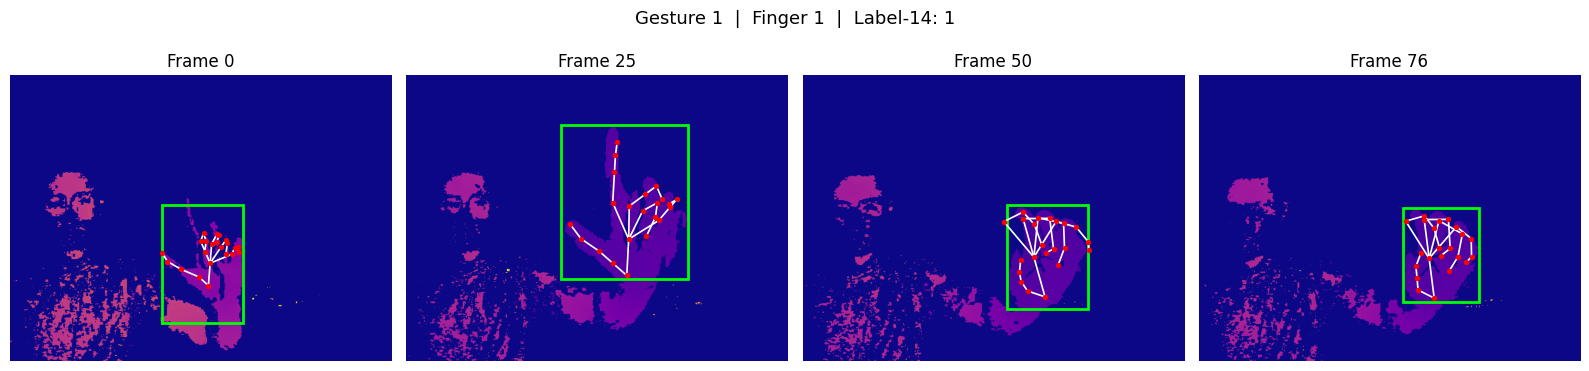

In [4]:
# Plot 4 evenly-spaced frames with bounding box + 2D skeleton overlay
BONES = np.array([
    [0,1],[0,2],[2,3],[3,4],[4,5],
    [1,6],[6,7],[7,8],[8,9],
    [1,10],[10,11],[11,12],[12,13],
    [1,14],[14,15],[15,16],[16,17],
    [1,18],[18,19],[19,20],[20,21]
])

frame_ids = np.linspace(0, n_frames - 1, 4, dtype=int)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, fid in zip(axes, frame_ids):
    depth_png = cpath / f'{fid}_depth.png'
    if not depth_png.exists():
        ax.set_title(f'Frame {fid} (missing)'); continue

    img = np.array(Image.open(depth_png))
    ax.imshow(img, cmap='plasma')

    # Draw bounding box
    x, y, w, h = bboxes[fid]
    rect = patches.Rectangle((x, y), w, h,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)

    # Draw skeleton
    ske = skel_img[fid]  # (22, 2) — columns are (u, v)
    for b in BONES:
        ax.plot([ske[b[0], 0], ske[b[1], 0]],
                [ske[b[0], 1], ske[b[1], 1]],
                'w-', lw=1.2)
    ax.scatter(ske[:, 0], ske[:, 1], c='red', s=8, zorder=5)
    ax.set_title(f'Frame {fid}')
    ax.axis('off')

fig.suptitle(f'Gesture {g}  |  Finger {f}  |  Label-14: {label_14}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Why 64×64? Why Crop? <a id='4'></a>

### Full frame vs. cropped ROI

```
Full depth frame (640×480):
┌──────────────────────────────────────┐
│                                      │
│         background / wall            │
│                                      │
│      ┌──────────┐  ← hand ROI        │
│      │  ✋ hand  │    ~100×100 px     │
│      └──────────┘                    │
│                                      │
└──────────────────────────────────────┘
```

The hand occupies roughly **100×100 px** in a 640×480 scene (~3% of pixels).  
Feeding the full frame to a CNN means 97% of the input contains irrelevant background, and the network must learn to ignore it — wasting capacity and requiring far more data.  
We use `general_informations.txt` (bounding box per frame) to crop and isolate the hand ROI before resizing.

### Why 64×64 and not 224×224?

| Spatial size | Tokens per frame (after 8×8 conv) | Memory per sample (T=16) | Notes |
|---|---|---|---|
| 32×32 | 16 | ~0.13 MB | Too small; fine texture lost |
| **64×64** | **64** | **~0.5 MB** | **Good balance — our choice** |
| 112×112 | 196 | ~1.5 MB | 3× more VRAM |
| 224×224 | 784 | ~6 MB | 12× more VRAM; overkill for hand-only |

At 64×64, joint positions and finger silhouettes are clearly preserved after cropping, and a batch of 32 samples fits in <1 GB GPU memory.


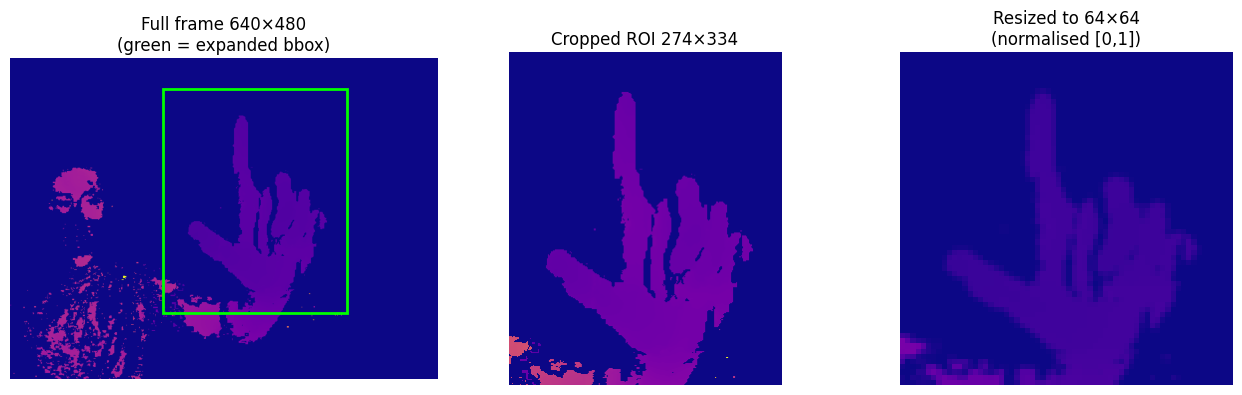

Crop size: (334, 274)  →  Final: (64, 64)


In [5]:
# Live demonstration: full frame → crop → resize
from preprocess_depth import _expand_bbox, crop_and_resize_frame

fid   = frame_ids[1]
frame = np.array(Image.open(cpath / f'{fid}_depth.png'), dtype=np.float32)
bbox  = bboxes[fid]
x, y, w, h = bbox
x1, y1, x2, y2 = _expand_bbox(x, y, w, h)
crop_raw  = frame[y1:y2, x1:x2]
processed = crop_and_resize_frame(frame, bbox, size=64)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(frame, cmap='plasma')
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                           lw=2, edgecolor='lime', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title(f'Full frame 640×480\n(green = expanded bbox)')

axes[1].imshow(crop_raw, cmap='plasma')
axes[1].set_title(f'Cropped ROI {crop_raw.shape[1]}×{crop_raw.shape[0]}')

axes[2].imshow(processed, cmap='plasma', vmin=0, vmax=1)
axes[2].set_title(f'Resized to 64×64\n(normalised [0,1])')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Crop size: {crop_raw.shape}  →  Final: {processed.shape}')

---
## 5. Preprocess — Skeleton Modality <a id='5'></a>

**Flow:**
```
skeletons_world.txt (N,66)
       ↓ reshape
    (N, 22, 3)  raw world coords
       ↓ root-normalise (subtract wrist)
    (N, 22, 3)  translation-invariant
       ↓ scale-normalise (÷ max pairwise dist)
    (N, 22, 3)  size-invariant
       ↓ sliding window T=16, stride=4
    list of (16, 22, 3) windows
       ↓ augment (train only)
    → stacked (M, 16, 22, 3)  + labels (M,)
       ↓ save
    skeleton_{train,val,test}.npz
```

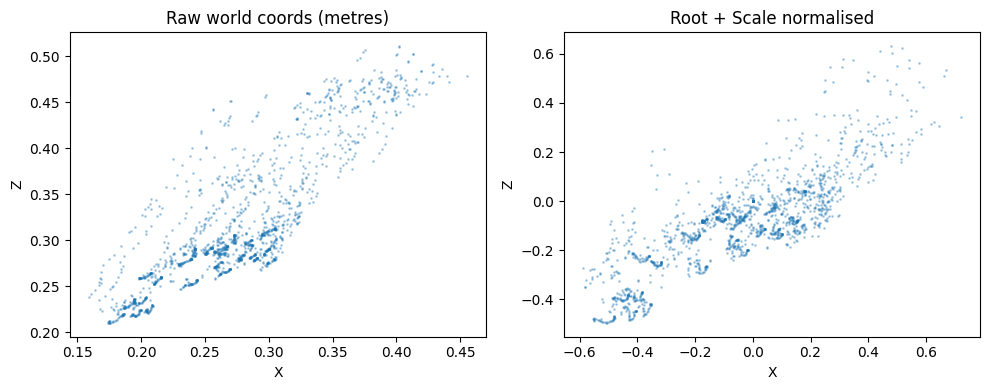

Raw  range: X=[0.159, 0.455]
Norm range: X=[-0.589, 0.722]


In [6]:
# Inspect normalisation on our example clip
skel_raw  = skel_world.copy()          # (N, 22, 3)
skel_norm = normalise_clip(skel_raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, skel, title in zip(
        axes,
        [skel_raw, skel_norm],
        ['Raw world coords (metres)', 'Root + Scale normalised']):
    ax.scatter(skel[:, :, 0].flatten(),
               skel[:, :, 2].flatten(), s=1, alpha=0.3)
    ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_title(title)
plt.tight_layout()
plt.show()
print(f'Raw  range: X=[{skel_raw[:,:,0].min():.3f}, {skel_raw[:,:,0].max():.3f}]')
print(f'Norm range: X=[{skel_norm[:,:,0].min():.3f}, {skel_norm[:,:,0].max():.3f}]')

In [7]:
# Temporal windowing demo
windows = sliding_windows(skel_norm, T=WINDOW_T, stride=STRIDE)
print(f'Clip length: {len(skel_norm)} frames  →  {len(windows)} windows '
      f'(T={WINDOW_T}, stride={STRIDE})')
print(f'Window shape: {windows[0].shape}')

Clip length: 77 frames  →  16 windows (T=16, stride=4)
Window shape: (16, 22, 3)


In [8]:
# ── Run full preprocessing (uncomment to execute) ──────────────────────────
# This writes skeleton_{train,val,test}.npz to dataset/processed/
# Expected runtime: ~2-5 min depending on hardware

# import preprocess_skeleton
# preprocess_skeleton.run(use_28_class=False, n_aug=3)


---
## 6. Preprocess — Depth Map Modality <a id='6'></a>

**Flow:**
```
{0..N-1}_depth.png   (N, 480, 640)  uint16 mm values
       ↓  general_informations.txt → bounding box per frame
    crop hand ROI  (N, H_roi, W_roi)
       ↓  clip to DEPTH_MAX_MM, divide → [0,1]
    normalised crop  (N, H_roi, W_roi)
       ↓  PIL.resize(64, 64) BILINEAR
    (N, 64, 64)
       ↓  sliding window T=16, stride=4
    list of (16, 64, 64) windows
       ↓  augment (train only)
    → (M, 16, 64, 64)  + labels (M,)
       ↓  save
    depth_{train,val,test}.npz
```

In [9]:
# Inspect processed depth sequence for the example clip
depth_seq = process_depth_clip(cpath, n_frames, size=64)  # (N, 64, 64)
print(f'Depth sequence shape: {depth_seq.shape}  dtype: {depth_seq.dtype}')
print(f'Value range: [{depth_seq.min():.4f}, {depth_seq.max():.4f}]')

wins_d = sliding_windows_depth(depth_seq, T=WINDOW_T, stride=STRIDE)
print(f'Windows: {len(wins_d)}  each shape: {wins_d[0].shape}')

Depth sequence shape: (77, 64, 64)  dtype: float32
Value range: [0.0000, 0.2980]
Windows: 16  each shape: (16, 64, 64)


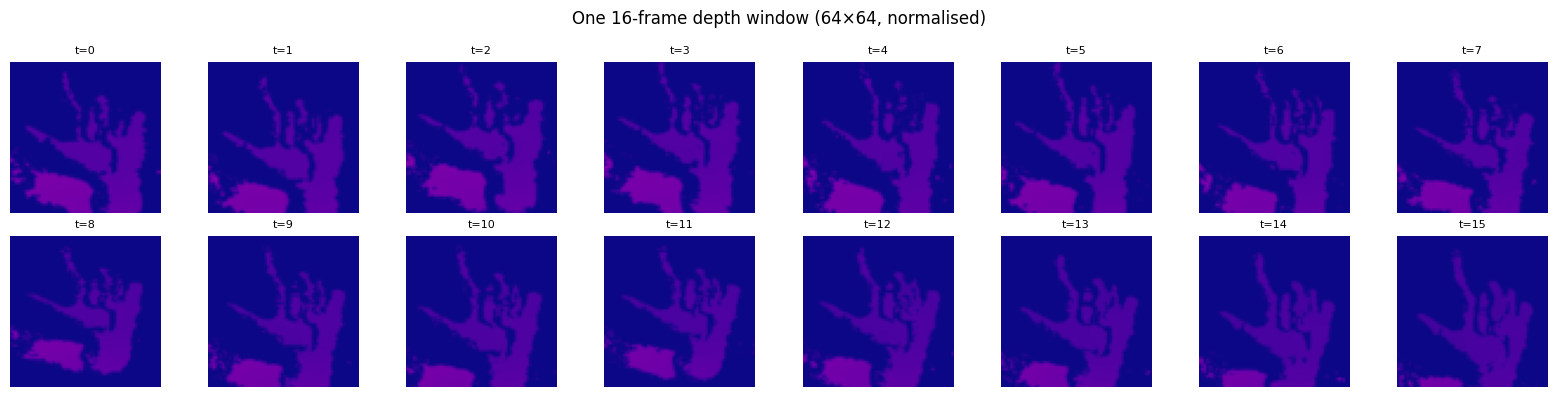

In [10]:
# Show a 16-frame window as a grid
win = wins_d[0]  # (16, 64, 64)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(win[i], cmap='plasma', vmin=0, vmax=1)
    ax.set_title(f't={i}', fontsize=8)
    ax.axis('off')
fig.suptitle('One 16-frame depth window (64×64, normalised)', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# ── Run full preprocessing (uncomment to execute) ──────────────────────────
# This writes depth_{train,val,test}.npz to dataset/processed/
# Expected runtime: ~10-25 min (reads PNG files from disk)

import preprocess_depth
preprocess_depth.run(use_28_class=False, n_aug=3)


=== Building depth dataset ===
[1/3] Processing test split …


clips: 100%|██████████| 840/840 [03:19<00:00,  4.22it/s]


  test  → X(9611, 16, 64, 64)  y(9611,)  clip_ids(9611,)
[2/3] Processing train split (with augmentation) …


clips: 100%|██████████| 1960/1960 [20:41<00:00,  1.58it/s]


  all   → X(88792, 16, 64, 64)  y(88792,)  clip_ids(88792,)
[3/3] Stratified train/val split …
  train → X(75473, 16, 64, 64)  y(75473,)  clip_ids(75473,)
  val   → X(13319, 16, 64, 64)    y(13319,)    clip_ids(13319,)
Done.


---
## 7. Verify Processed Tensors & Class Distribution <a id='7'></a>

Skeleton — train: 75473  val: 13319  test: 9611
Sample shape: X=torch.Size([16, 22, 3])  y=10


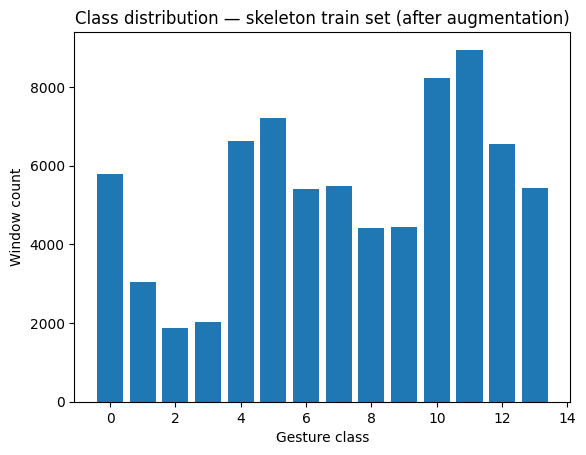

In [12]:
# ── Uncomment after running preprocessing ─────────────────────────────────

from torch.utils.data import DataLoader

ds_train = SkeletonDataset(PROC_SKELETON_TRAIN)
ds_val   = SkeletonDataset(PROC_SKELETON_VAL)
ds_test  = SkeletonDataset(PROC_SKELETON_TEST)

print(f'Skeleton — train: {len(ds_train)}  val: {len(ds_val)}  test: {len(ds_test)}')
x, y = ds_train[0]
print(f'Sample shape: X={x.shape}  y={y}')

# Class distribution after augmentation
all_labels = np.array([ds_train[i][1].item() for i in range(len(ds_train))])
labels, counts = np.unique(all_labels, return_counts=True)
plt.bar(labels, counts)
plt.xlabel('Gesture class'); plt.ylabel('Window count')
plt.title('Class distribution — skeleton train set (after augmentation)')
plt.show()


---
## 8. Augmentation Preview <a id='8'></a>

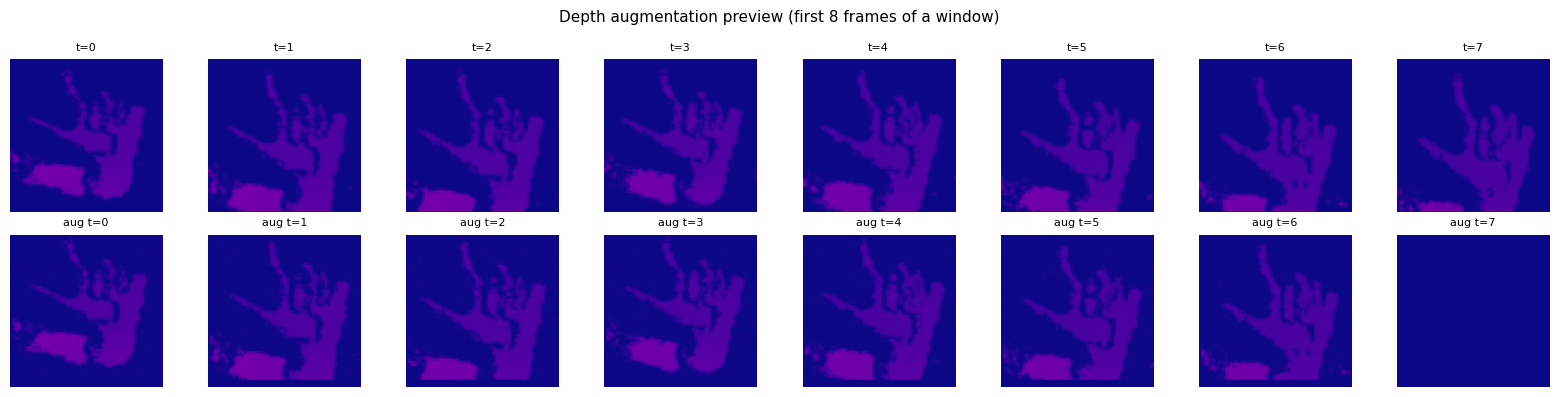

In [13]:
# Compare original vs augmented depth window
rng = np.random.default_rng(0)
win_aug = augment_depth(wins_d[2], rng)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(wins_d[2][i], cmap='plasma', vmin=0, vmax=1)
    axes[0, i].set_title(f't={i}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(win_aug[i], cmap='plasma', vmin=0, vmax=1)
    axes[1, i].set_title(f'aug t={i}', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, rotation=90)
axes[1, 0].set_ylabel('Augmented', fontsize=10, rotation=90)
fig.suptitle('Depth augmentation preview (first 8 frames of a window)', fontsize=11)
plt.tight_layout()
plt.show()

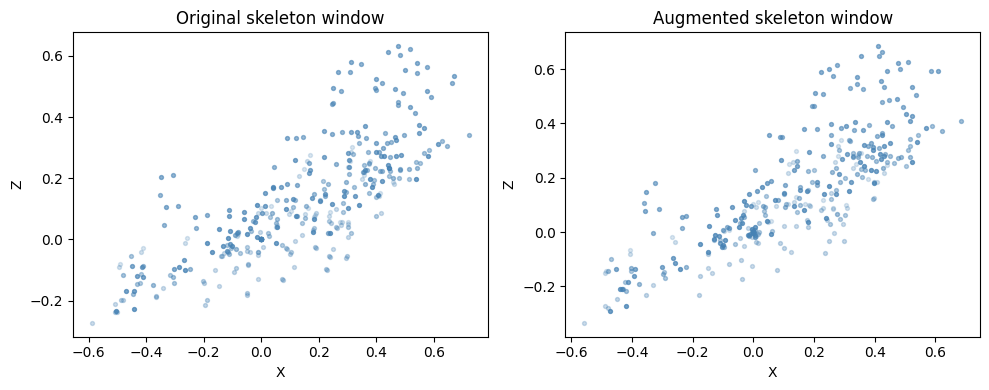

In [14]:
# Compare original vs augmented skeleton window
rng2   = np.random.default_rng(42)
win_sk = windows[0]
win_sk_aug = augment_skeleton(win_sk, rng2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, skel, title in zip(axes,
                             [win_sk, win_sk_aug],
                             ['Original skeleton window', 'Augmented skeleton window']):
    for t in range(WINDOW_T):
        alpha = 0.2 + 0.6 * t / WINDOW_T
        ax.scatter(skel[t, :, 0], skel[t, :, 2], s=8, alpha=alpha, color='steelblue')
    ax.set_xlabel('X'); ax.set_ylabel('Z')
    ax.set_title(title)
plt.tight_layout()
plt.show()